In [1]:
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [2]:
df = pd.read_csv("Iris.csv")

In [3]:
X = df.drop(columns=["Species"])

y = df["Species"]

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [5]:
print(X_scaled[:5])

[[-1.72054204 -0.90068117  1.03205722 -1.3412724  -1.31297673]
 [-1.69744751 -1.14301691 -0.1249576  -1.3412724  -1.31297673]
 [-1.67435299 -1.38535265  0.33784833 -1.39813811 -1.31297673]
 [-1.65125846 -1.50652052  0.10644536 -1.2844067  -1.31297673]
 [-1.62816394 -1.02184904  1.26346019 -1.3412724  -1.31297673]]


In [6]:
import matplotlib.pyplot as plt


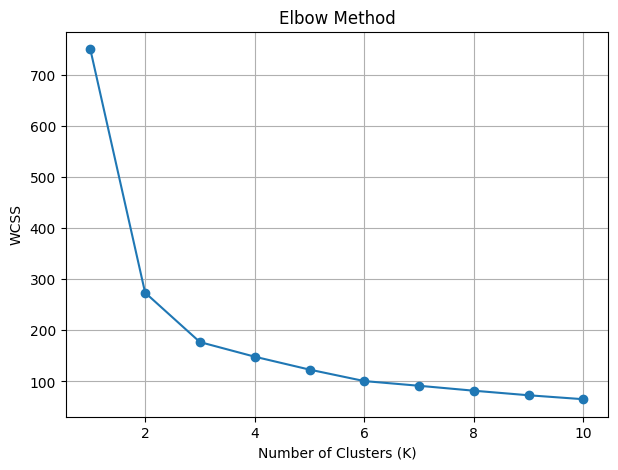

In [8]:

wcss = []

for k in range(1, 11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    wcss.append(model.inertia_)

plt.figure(figsize=(7,5))

plt.plot(range(1,11), wcss, marker="o")

plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.grid(True)

plt.show()

In [9]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

kmeans.fit(X_scaled)

,n_clusters,3
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [10]:
clusters = kmeans.labels_
print(clusters)

[2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 0 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 0 0 0 1 0 0 0 0
 0 0 1 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0]


In [12]:
df["Cluster"] = clusters


In [13]:
print(df.head())

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species  \
0   1            5.1           3.5            1.4           0.2  Iris-setosa   
1   2            4.9           3.0            1.4           0.2  Iris-setosa   
2   3            4.7           3.2            1.3           0.2  Iris-setosa   
3   4            4.6           3.1            1.5           0.2  Iris-setosa   
4   5            5.0           3.6            1.4           0.2  Iris-setosa   

   Cluster  
0        2  
1        2  
2        2  
3        2  
4        2  


In [14]:
print(kmeans.cluster_centers_)

[[ 1.14317894  1.03542672 -0.07079946  1.04224753  1.09269889]
 [ 0.07560189  0.03894137 -0.73184462  0.30676007  0.21508647]
 [-1.1547262  -1.01457897  0.84230679 -1.30487835 -1.25512862]]


In [15]:
print(kmeans.n_iter_)

9


In [16]:
print("WCSS =", kmeans.inertia_)

WCSS = 177.05608895062974


In [17]:
score = silhouette_score(
    X_scaled,
    clusters
)

print("Silhouette Score =", score)

Silhouette Score = 0.452949780355554


In [18]:
print(df["Cluster"].value_counts())

Cluster
1    53
2    50
0    47
Name: count, dtype: int64


In [19]:
print(
    pd.crosstab(
        df["Species"],
        df["Cluster"]
    )
)

Cluster           0   1   2
Species                    
Iris-setosa       0   0  50
Iris-versicolor   2  48   0
Iris-virginica   45   5   0


In [20]:
import matplotlib.pyplot as plt


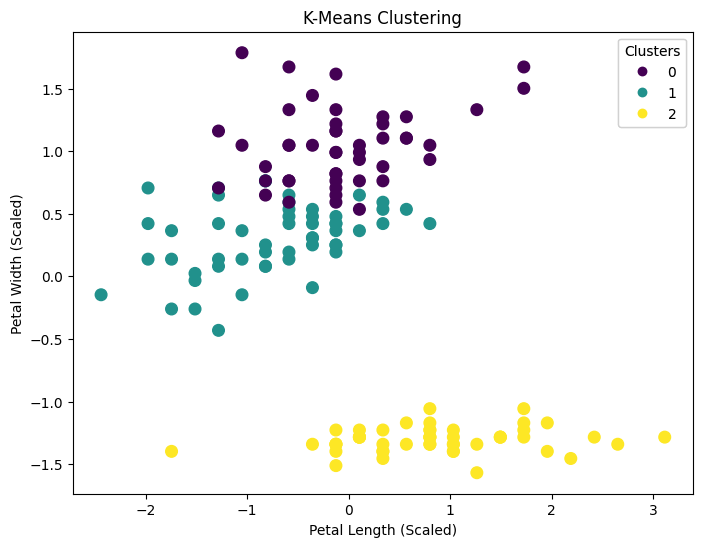

In [23]:

clusters = kmeans.labels_

plt.figure(figsize=(8,6))

scatter =plt.scatter(
    X_scaled[:, 2],     # PetalLengthCm
    X_scaled[:, 3],     # PetalWidthCm
    c=clusters,
    cmap="viridis",
    s=70
)

plt.xlabel("Petal Length (Scaled)")
plt.ylabel("Petal Width (Scaled)")
plt.title("K-Means Clustering")
# Add legend
legend = plt.legend(
    *scatter.legend_elements(),
    title="Clusters"
)

plt.gca().add_artist(legend)
plt.show()

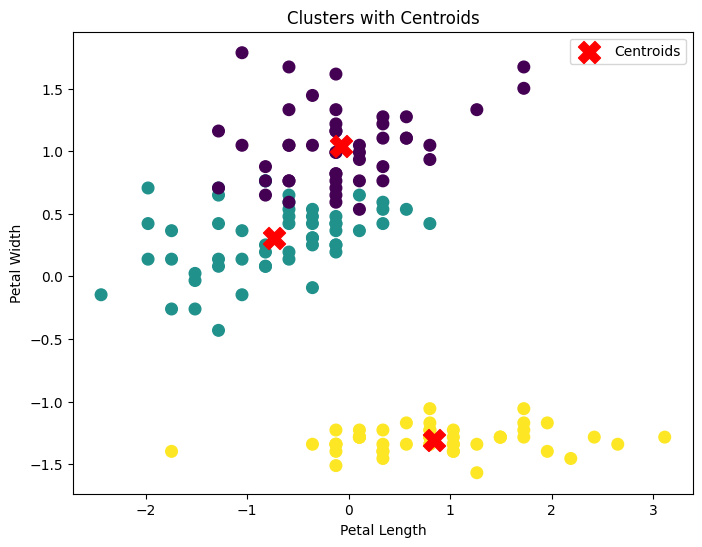

In [24]:
centers = kmeans.cluster_centers_

plt.figure(figsize=(8,6))

plt.scatter(
    X_scaled[:,2],
    X_scaled[:,3],
    c=kmeans.labels_,
    cmap="viridis",
    s=70
)

plt.scatter(
    centers[:,2],
    centers[:,3],
    c="red",
    marker="X",
    s=250,
    label="Centroids"
)

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")

plt.legend()

plt.title("Clusters with Centroids")

plt.show()

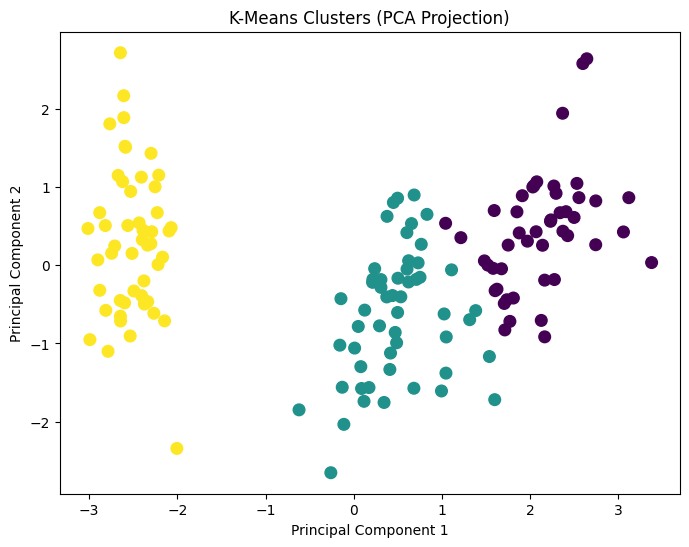

In [25]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=kmeans.labels_,
    cmap="viridis",
    s=70
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title("K-Means Clusters (PCA Projection)")

plt.show()

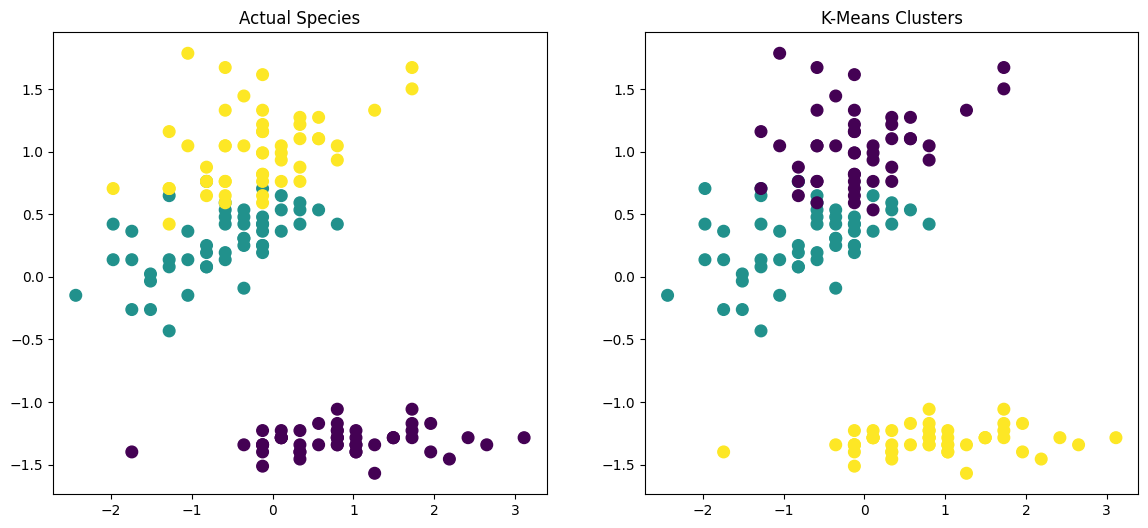

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))

# True Labels
axes[0].scatter(
    X_scaled[:,2],
    X_scaled[:,3],
    c=pd.factorize(df["Species"])[0],
    cmap="viridis",
    s=70
)

axes[0].set_title("Actual Species")

# Predicted Clusters
axes[1].scatter(
    X_scaled[:,2],
    X_scaled[:,3],
    c=kmeans.labels_,
    cmap="viridis",
    s=70
)

axes[1].set_title("K-Means Clusters")

plt.show()